In [38]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
from pathlib import Path

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

In [40]:
df.info()

print("\n--- missing counts ---")
print(df.isna().sum())

print("\n--- missing as fraction ---")
print(df.isna().mean().round(3))

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

--- missing counts ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: 

In [41]:
data = df.copy()

# 1. Cabin: 77% missing — drop the whole column, not the rows
data = data.drop(columns=["Cabin"])

# 2. Embarked: only 2 rows missing — drop those rows
data = data.dropna(subset=["Embarked"])

# 3. Identifier columns with no predictive signal
data = data.drop(columns=["PassengerId", "Name", "Ticket"])

print(data.shape)
print(data.isna().sum())

(889, 8)
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64


In [42]:
from sklearn.model_selection import train_test_split

y = data["Survived"]                    # the target: what we predict
X = data.drop(columns=["Survived"])     # the features: everything else

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (711, 7)  X_test: (178, 7)
y_train: (711,)  y_test: (178,)


In [43]:
age_median = X_train["Age"].median()          # learned from TRAIN only

X_train["Age"] = X_train["Age"].fillna(age_median)
X_test["Age"]  = X_test["Age"].fillna(age_median)   # same number, applied to test

print("median age (from train only):", age_median)
print("train Age missing:", X_train["Age"].isna().sum())
print("test  Age missing:", X_test["Age"].isna().sum())

median age (from train only): 28.0
train Age missing: 0
test  Age missing: 0


In [44]:
X_train = pd.get_dummies(X_train, columns=["Sex", "Embarked"])
X_test  = pd.get_dummies(X_test,  columns=["Sex", "Embarked"])

# keep test's columns identical to train's, in the same order
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# the new Sex_* / Embarked_* columns are booleans — cast ONLY those to 0/1
bool_cols = X_train.select_dtypes("bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)

print(X_train.shape, X_test.shape)
print(X_train.columns.tolist())
print(X_train.dtypes)

(711, 10)

 (178, 10)
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_female      int64
Sex_male        int64
Embarked_C      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object


In [45]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

train_acc = clf.score(X_train, y_train)
test_acc  = clf.score(X_test, y_test)

print(f"train accuracy: {train_acc:.3f}")
print(f"test  accuracy: {test_acc:.3f}")
print("depth:", clf.get_depth(), " leaves:", clf.get_n_leaves())

train accuracy: 0.985
test  accuracy: 0.770
depth: 17  leaves: 163


UNPRUNED -> depth 17, leaves 163, train 0.985, test 0.770


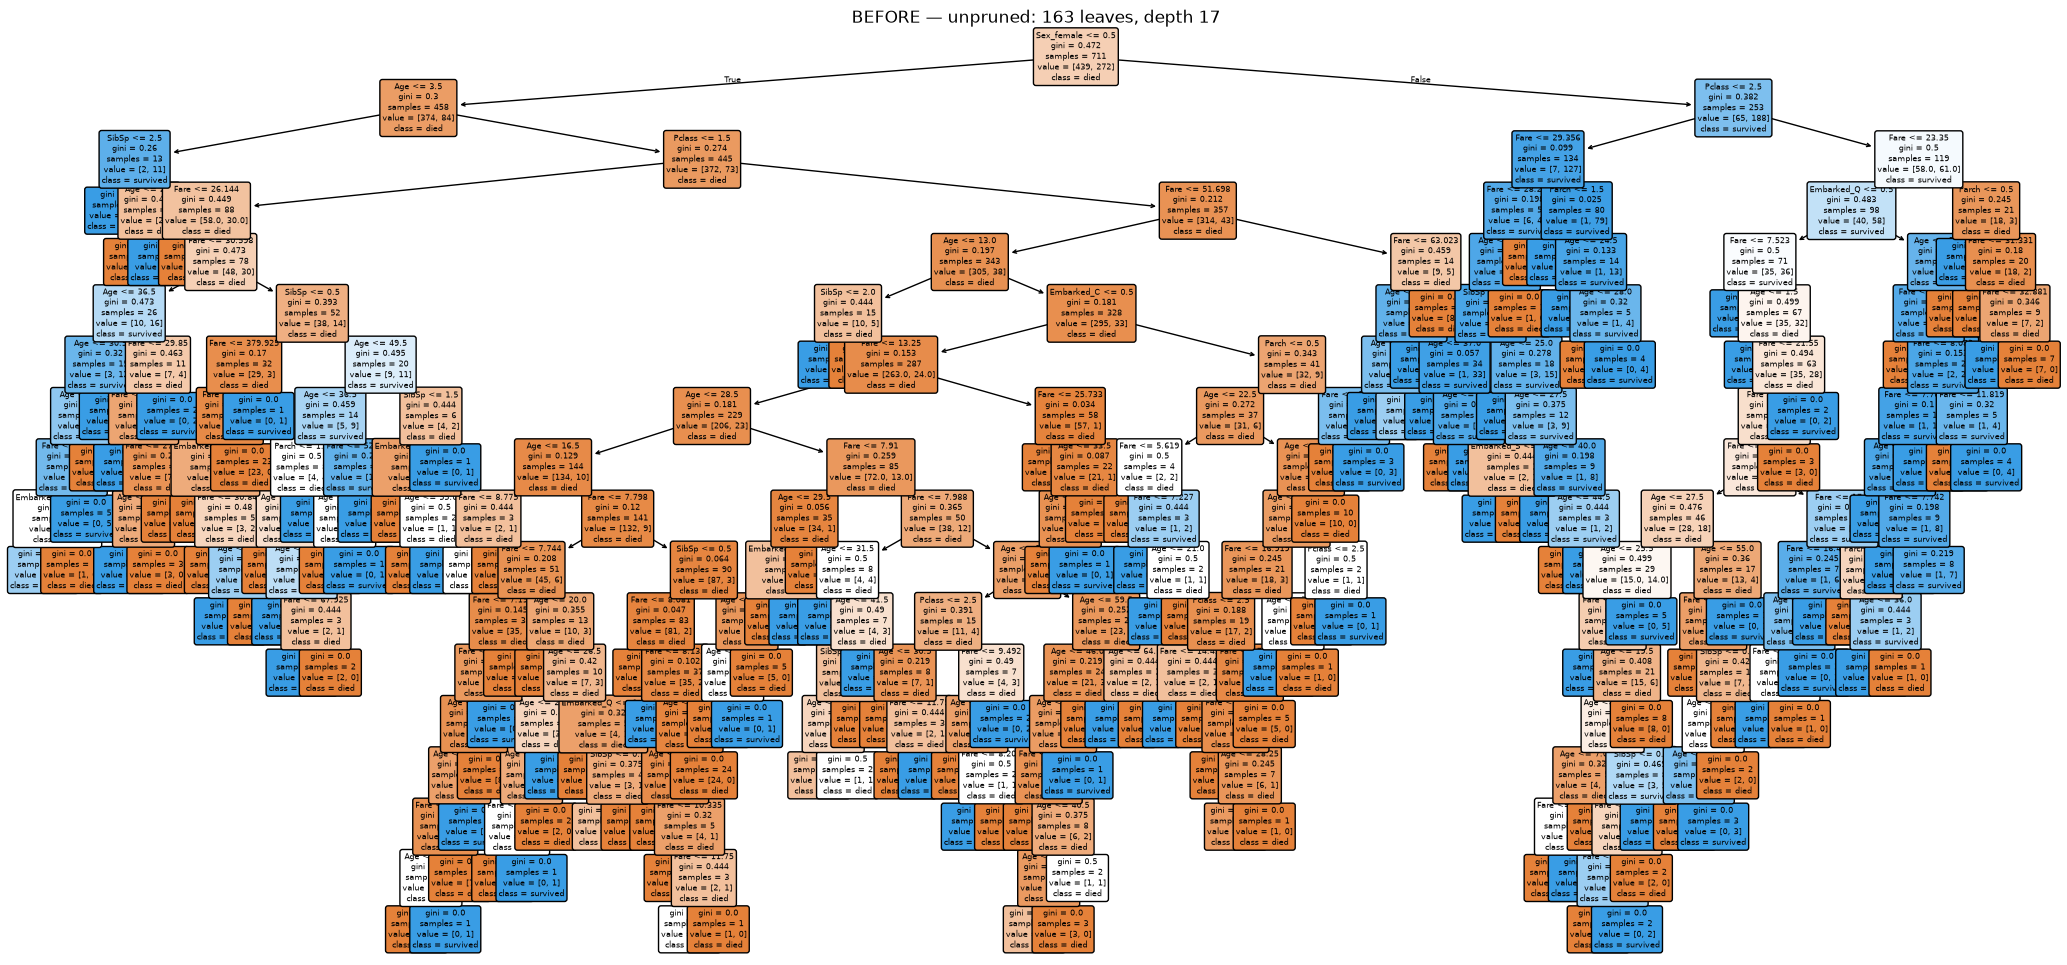

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

print(f"UNPRUNED -> depth {clf.get_depth()}, leaves {clf.get_n_leaves()}, "
      f"train {clf.score(X_train, y_train):.3f}, test {clf.score(X_test, y_test):.3f}")

plt.figure(figsize=(26, 12))
plot_tree(
    clf,
    feature_names=list(X_train.columns),
    class_names=["died", "survived"],
    filled=True, rounded=True, fontsize=6,
)
plt.title(f"BEFORE — unpruned: {clf.get_n_leaves()} leaves, depth {clf.get_depth()}")
plt.savefig(figures_dir / "tree_before_unpruned.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow.fit(X_train, y_train)

print(f"train accuracy: {shallow.score(X_train, y_train):.3f}")
print(f"test  accuracy: {shallow.score(X_test, y_test):.3f}")
print("depth:", shallow.get_depth(), " leaves:", shallow.get_n_leaves())

train accuracy: 0.826
test  accuracy: 0.815
depth: 3  leaves: 8


In [48]:
from sklearn.model_selection import cross_val_score

for d in range(1, 13):
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(f"depth {d:2d}  cv-mean {scores.mean():.3f}  cv-std {scores.std():.3f}")

depth  1  cv-mean 0.790  cv-std 0.013
depth  2  cv-mean 0.793  cv-std 0.007
depth  3  cv-mean 0.812  cv-std 0.013
depth  4  cv-mean 0.813  cv-std 0.014
depth  5  cv-mean 0.805  cv-std 0.020
depth  6  cv-mean 0.797  cv-std 0.016
depth  7  cv-mean 0.803  cv-std 0.025
depth  8  cv-mean 0.806  cv-std 0.033
depth  9  cv-mean 0.792  cv-std 0.017
depth 10  cv-mean 0.805  cv-std 0.032
depth 11  cv-mean 0.805  cv-std 0.021
depth 12  cv-mean 0.782  cv-std 0.032


In [49]:
import numpy as np

full = DecisionTreeClassifier(random_state=42)
alphas = full.cost_complexity_pruning_path(X_train, y_train).ccp_alphas

results = []
for a in alphas:
    cv = cross_val_score(DecisionTreeClassifier(random_state=42, ccp_alpha=a),
                         X_train, y_train, cv=5, scoring="accuracy")
    leaves = DecisionTreeClassifier(random_state=42, ccp_alpha=a).fit(X_train, y_train).get_n_leaves()
    results.append((a, leaves, cv.mean(), cv.std()))

print(len(alphas), "alphas; range %.5f..%.5f" % (alphas.min(), alphas.max()))
print(" alpha     leaves  cv-mean  cv-std")
for a, lv, mn, sd in results[::8]:          # every 8th row, to see the trend
    print(" %.5f  %4d    %.3f   %.3f" % (a, lv, mn, sd))

best = max(results, key=lambda r: r[2])
print("best cv: alpha %.5f  leaves %d  cv %.3f" % (best[0], best[1], best[2]))

70 alphas; range 0.00000..0.14360
 alpha     leaves  cv-mean  cv-std
 0.00000   163    0.768   0.031
 0.00023   153    0.768   0.031
 0.00085   135    0.769   0.030
 0.00108   102    0.776   0.029
 0.00125    84    0.786   0.026
 0.00144    56    0.792   0.019
 0.00183    37    0.806   0.019
 0.00269    20    0.807   0.029
 0.00558     6    0.806   0.016
best cv: alpha 0.00191  leaves 35  cv 0.810


In [50]:
best_mean = max(m for _, _, m, _ in results)
best_std  = next(s for _, _, m, s in results if m == best_mean)
se = best_std / np.sqrt(5)
threshold = best_mean - se

# among models within 1 SE of the best, take the one with the LARGEST alpha (simplest)
within = [(a, lv, m) for (a, lv, m, s) in results if m >= threshold]
final_alpha, final_leaves, final_cv = max(within, key=lambda r: r[0])

print(f"best cv-mean {best_mean:.3f},  1-SE threshold {threshold:.3f}")
print(f"1-SE pick -> alpha {final_alpha:.5f},  leaves {final_leaves},  cv {final_cv:.3f}")

final_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=final_alpha)
final_tree.fit(X_train, y_train)
print(f"final tree -> depth {final_tree.get_depth()},  leaves {final_tree.get_n_leaves()},  "
      f"train acc {final_tree.score(X_train, y_train):.3f}")

best cv-mean 0.810,  1-SE threshold 0.799
1-SE pick -> alpha 0.00558,  leaves 6,  cv 0.806
final tree -> depth 3,  leaves 6,  train acc 0.824


test accuracy: 0.798

              precision    recall  f1-score   support

        died      0.808     0.882     0.843       110
    survived      0.776     0.662     0.714        68

    accuracy                          0.798       178
   macro avg      0.792     0.772     0.779       178
weighted avg      0.796     0.798     0.794       178



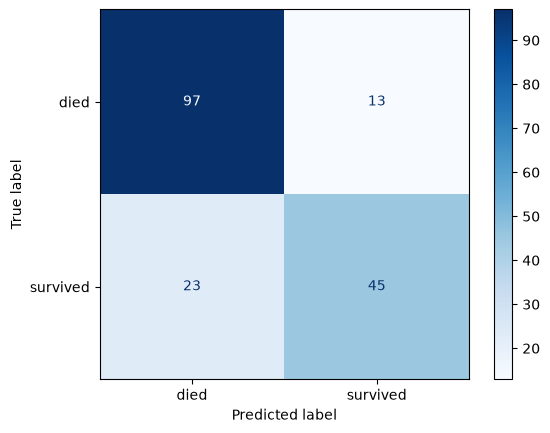

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_pred = final_tree.predict(X_test)

print("test accuracy:", round(final_tree.score(X_test, y_test), 3))
print()
print(classification_report(y_test, y_pred, target_names=["died", "survived"], digits=3))

ConfusionMatrixDisplay.from_estimator(
    final_tree, X_test, y_test,
    display_labels=["died", "survived"], cmap="Blues"
)
plt.show()

Sex_female    0.674
Pclass        0.203
Age           0.078
Fare          0.046
Parch         0.000
SibSp         0.000
Sex_male      0.000
Embarked_C    0.000
Embarked_Q    0.000
Embarked_S    0.000


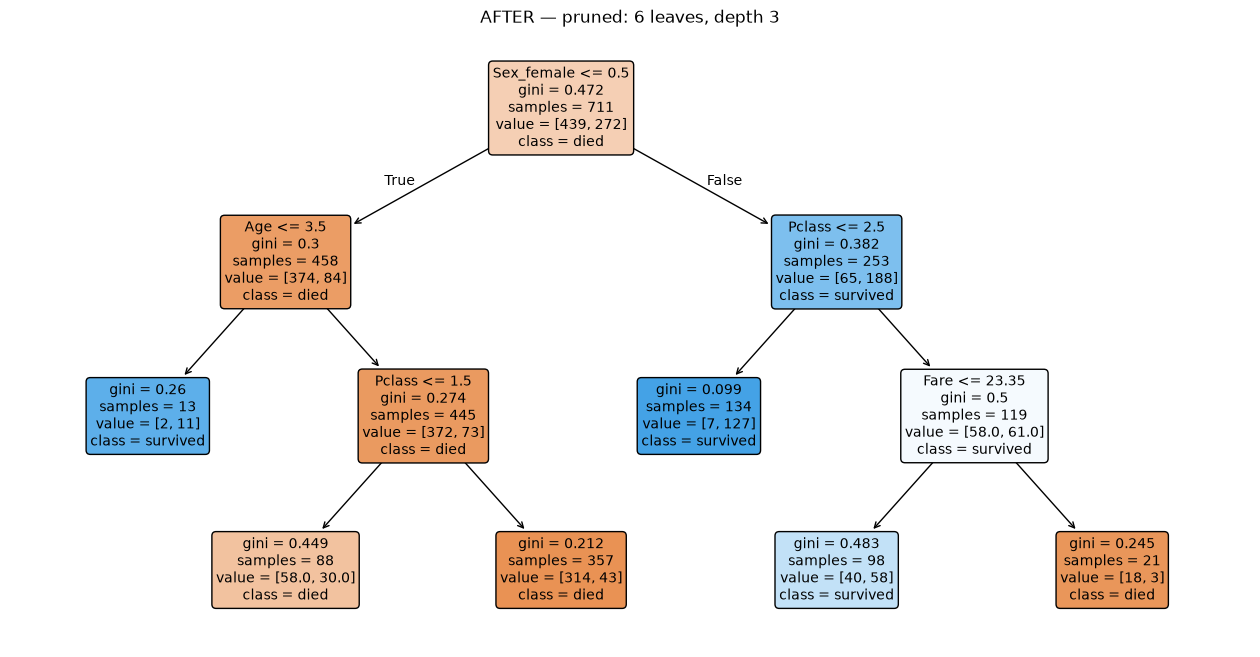

In [52]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

importances = pd.Series(final_tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.round(3).to_string())

plt.figure(figsize=(16, 8))
plot_tree(
    final_tree,
    feature_names=list(X_train.columns),
    class_names=["died", "survived"],
    filled=True, rounded=True, fontsize=10,
)
plt.title(f"AFTER — pruned: {final_tree.get_n_leaves()} leaves, depth {final_tree.get_depth()}")
plt.savefig(figures_dir / "tree_after_pruned.png", dpi=300, bbox_inches="tight")
plt.show()

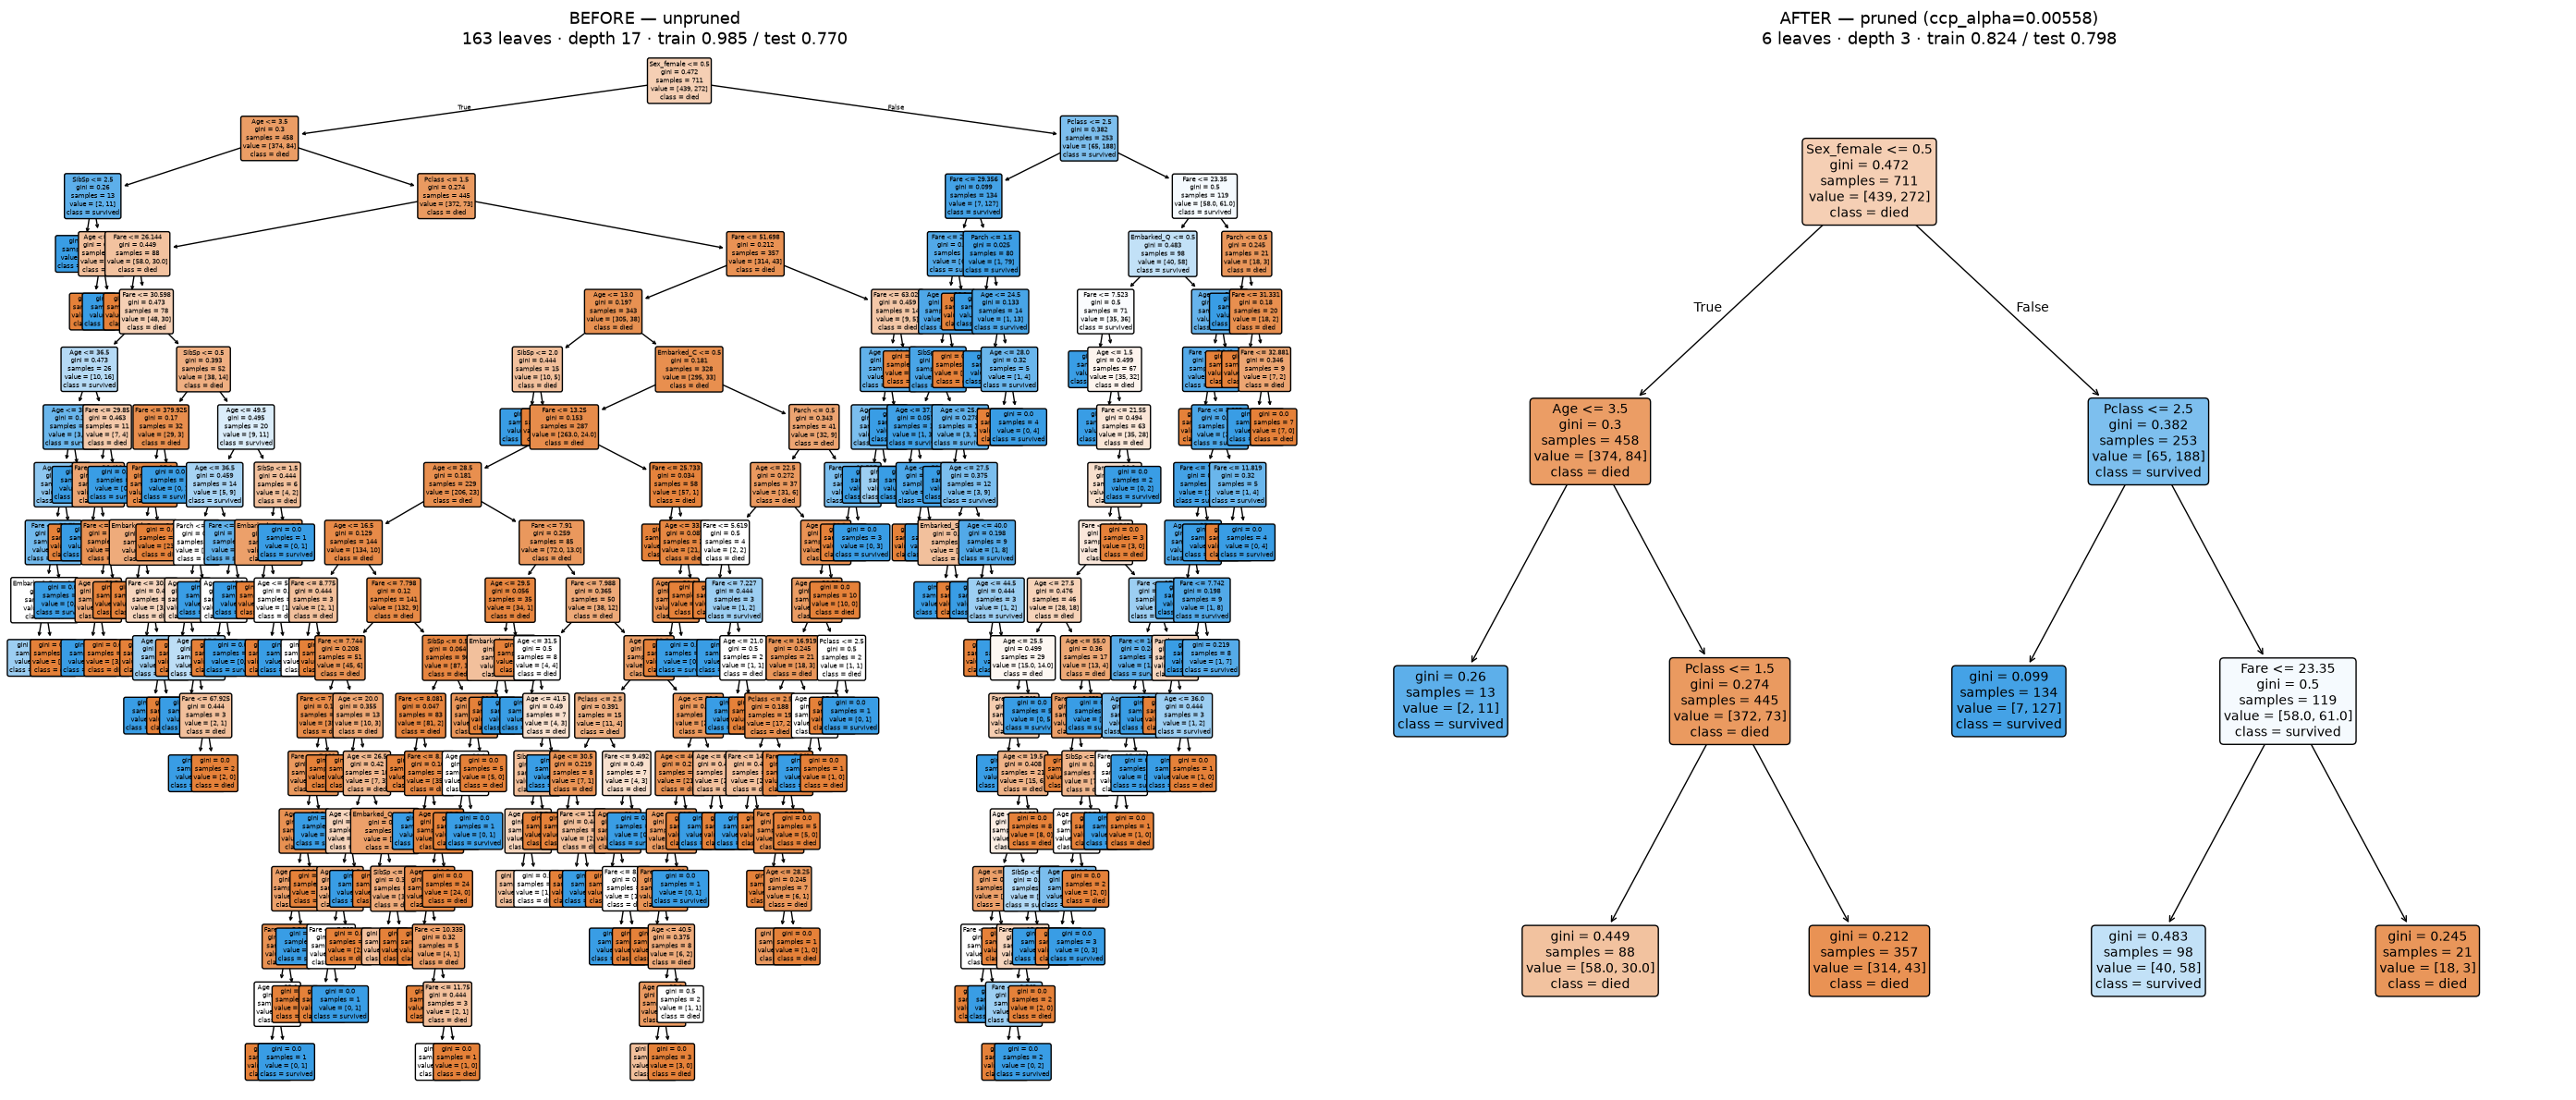

In [53]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

# BEFORE — the unpruned tree from Section 7
plot_tree(clf, feature_names=list(X_train.columns), class_names=["died", "survived"],
          filled=True, rounded=True, fontsize=5, ax=axes[0])
axes[0].set_title(
    f"BEFORE — unpruned\n{clf.get_n_leaves()} leaves · depth {clf.get_depth()} · "
    f"train {clf.score(X_train, y_train):.3f} / test {clf.score(X_test, y_test):.3f}",
    fontsize=13)

# AFTER — the pruned tree from Section 11
plot_tree(final_tree, feature_names=list(X_train.columns), class_names=["died", "survived"],
          filled=True, rounded=True, fontsize=10, ax=axes[1])
axes[1].set_title(
    f"AFTER — pruned (ccp_alpha=0.00558)\n{final_tree.get_n_leaves()} leaves · depth {final_tree.get_depth()} · "
    f"train {final_tree.score(X_train, y_train):.3f} / test {final_tree.score(X_test, y_test):.3f}",
    fontsize=13)

plt.tight_layout()
fig.savefig(figures_dir / "tree_before_after.png", dpi=200, bbox_inches="tight")
plt.show()

In [54]:
print("saving into:", figures_dir.resolve())

saving into: C:\Users\AREZA\Desktop\titanic-decision-tree\figures
